For questions 1, 2, and 3: 

Use only the provided dataset
- Scale the features using StandardScaler() from sklearn.preprocessing
- Apply K-means clustering using KMeans() from sklearn.cluster with the following settings: 
- Set init = 'random' (this will make it so that the initial centroids are randomly assigned)
- Set random_state = 9001 (this will allow us to compare your results with our own)
- Set n_init = 20 (as we are going for randomly assigned initial centroids, this will make it so that the algorithm runs twenty times with the best output in terms of inertial being displayed)
- Search for K in {2, 3, 4, 5, 6} 
    - For each K, fit the model on the scaled features and compute 
        - Inertia (WCSS) 
        - Average silhouette score; you may use use silhouette_score() from sklearn.metrics to obtain this
        - Elbow check: compute the drop in inertia for all K values and identify the largest drop across the tested values; this is the optimal K value using the elbow method
        - For each K value, report the cluster counts (number of samples per cluster)
 

- Questions 4 and 5 are conceptual theory-based questions and do not involve any coding. 

 

In [13]:
import pandas as pd

In [14]:
df = pd.read_csv("carprices.csv")
df.sample(3)
df.shape


(205, 4)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   enginesize  205 non-null    int64
 1   horsepower  205 non-null    int64
 2   citympg     205 non-null    int64
 3   highwaympg  205 non-null    int64
dtypes: int64(4)
memory usage: 6.5 KB


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
enginesize,205.0,126.907317,41.642693,61.0,97.0,120.0,141.0,326.0
horsepower,205.0,104.117073,39.544167,48.0,70.0,95.0,116.0,288.0
citympg,205.0,25.219512,6.542142,13.0,19.0,24.0,30.0,49.0
highwaympg,205.0,30.751220,6.886443,16.0,25.0,30.0,34.0,54.0


In [17]:
df.head()

,enginesize,horsepower,citympg,highwaympg
0,130,111,21,27
1,130,111,21,27
2,152,154,19,26
3,109,102,24,30
4,136,115,18,22


In [23]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
dfs = scaler.fit_transform(df)
type(dfs)
df_scaled = pd.DataFrame(dfs, columns = df.columns)

- Apply K-means clustering using KMeans() from sklearn.cluster with the following settings: 
- Set init = 'random' (this will make it so that the initial centroids are randomly assigned)
- Set random_state = 9001 (this will allow us to compare your results with our own)
- Set n_init = 20 (as we are going for randomly assigned initial centroids, this will make it so that the algorithm runs twenty times with the best output in terms of 

In [22]:
from sklearn.cluster import KMeans
clusters = KMeans(n_clusters=3,
                init='random',
                n_init= 20,
                random_state=9001)
clusters.fit(df_scaled)
clusters.cluster_centers_

array([[-0.76217265, -0.93219388,  1.21229459,  1.19598842],
       [-0.16111868, -0.13308101, -0.22908128, -0.21778731],
       [ 1.35396005,  1.51969054, -1.11956531, -1.12200297]])

In [24]:
clusters.labels_ 

array([1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 1, 1, 1, 2, 2, 2, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 0, 1, 0, 0, 0, 1, 2, 2, 2, 2, 2, 2, 1, 1,
       1, 1, 1, 1, 2, 2, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 2, 2, 2, 2, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       2, 2, 1, 2, 2, 1, 1], dtype=int32)

In [25]:
import numpy as np

clusters.inertia_

234.45366600191429

In [26]:
scaler.inverse_transform(clusters.cluster_centers_)
pd.DataFrame(data = scaler.inverse_transform(clusters.cluster_centers_), columns = df.columns).round(2)

,enginesize,horsepower,citympg,highwaympg
0,95.25,67.34,33.13,38.97
1,120.21,98.87,23.72,29.26
2,183.15,164.07,17.91,23.04


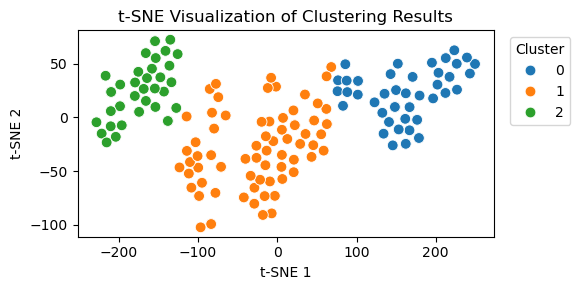

In [28]:
from sklearn.manifold import TSNE  # To visualise clustering results
import matplotlib.pyplot as plt; import seaborn as sns
tsne = TSNE(n_components = 2, random_state = 42)
tsnes = tsne.fit_transform(df_scaled)
df_tsne = pd.DataFrame({'TSNE1': tsnes[:, 0], 'TSNE2': tsnes[:, 1], 'Cluster': clusters.labels_})
plt.figure(figsize = (6, 3));
sns.scatterplot(data = df_tsne, x = 'TSNE1', y = 'TSNE2', hue = 'Cluster', palette = 'tab10', s = 60); 
plt.title('t-SNE Visualization of Clustering Results'); plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2'); 
plt.legend(title = 'Cluster', bbox_to_anchor = (1.2, 1)); plt.tight_layout();

In [31]:
# Cluster the data for different values of number of clusters and store the inertias of each clustering
inertias = []
for k in np.arange(2, 21, 1):
    clusters = KMeans(n_clusters = k, 
                      init='random',
                      n_init = 20,
                      random_state = 9001)
    clusters.fit(df_scaled)
    inertias.append(clusters.inertia_)
    print('Clustering with {} clusters has total WCSS of {}'.format(k, int(np.round(clusters.inertia_))))

Clustering with 2 clusters has total WCSS of 385
Clustering with 3 clusters has total WCSS of 234
Clustering with 4 clusters has total WCSS of 174
Clustering with 5 clusters has total WCSS of 134
Clustering with 6 clusters has total WCSS of 112
Clustering with 7 clusters has total WCSS of 101
Clustering with 8 clusters has total WCSS of 85
Clustering with 9 clusters has total WCSS of 73
Clustering with 10 clusters has total WCSS of 70
Clustering with 11 clusters has total WCSS of 60
Clustering with 12 clusters has total WCSS of 54
Clustering with 13 clusters has total WCSS of 52
Clustering with 14 clusters has total WCSS of 46
Clustering with 15 clusters has total WCSS of 44
Clustering with 16 clusters has total WCSS of 38
Clustering with 17 clusters has total WCSS of 38
Clustering with 18 clusters has total WCSS of 38
Clustering with 19 clusters has total WCSS of 34
Clustering with 20 clusters has total WCSS of 29


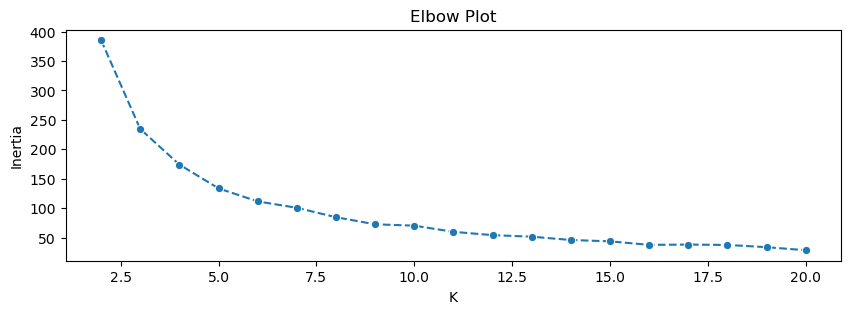

In [32]:
# Use the inertias to plot an elbow curve
plt.figure(figsize = (10, 3));
sns.lineplot(x = np.arange(2, 21, 1), 
             y = inertias, linestyle = '--', 
             marker = 'o'); plt.xlabel('K'); 
plt.ylabel('Inertia'); plt.title('Elbow Plot');

In [35]:
from sklearn.metrics import silhouette_score
# Cluster the data for different values of number of clusters and store the silhouette scores of each clustering
silhouettes = []
for k in np.arange(2, 21, 1):
    clusters = KMeans(n_clusters = k, random_state = 0)
    clusters.fit(dfs)
    silhouettes.append(silhouette_score(dfs, clusters.labels_))
    print('Clustering with {} clusters has total Silhouette score of {}'.format(k, np.round(silhouette_score(dfs, clusters.labels_), 2)))

Clustering with 2 clusters has total Silhouette score of 0.47
Clustering with 3 clusters has total Silhouette score of 0.45
Clustering with 4 clusters has total Silhouette score of 0.41
Clustering with 5 clusters has total Silhouette score of 0.38
Clustering with 6 clusters has total Silhouette score of 0.37
Clustering with 7 clusters has total Silhouette score of 0.43
Clustering with 8 clusters has total Silhouette score of 0.35
Clustering with 9 clusters has total Silhouette score of 0.36
Clustering with 10 clusters has total Silhouette score of 0.39
Clustering with 11 clusters has total Silhouette score of 0.38
Clustering with 12 clusters has total Silhouette score of 0.38
Clustering with 13 clusters has total Silhouette score of 0.39
Clustering with 14 clusters has total Silhouette score of 0.39
Clustering with 15 clusters has total Silhouette score of 0.4
Clustering with 16 clusters has total Silhouette score of 0.41
Clustering with 17 clusters has total Silhouette score of 0.4
Cl

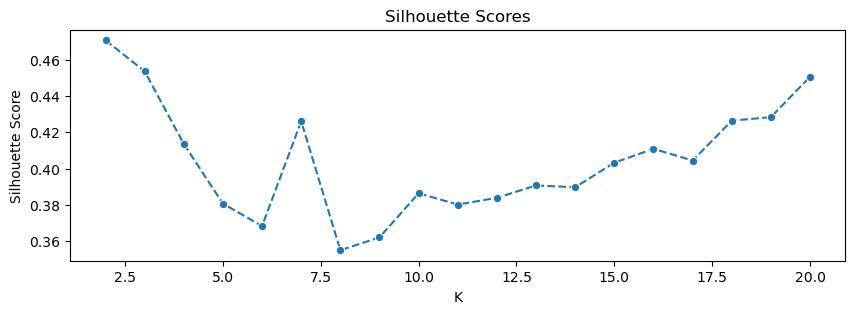

In [36]:
plt.figure(figsize = (10, 3)); sns.lineplot(x = np.arange(2, 21, 1), y = silhouettes, linestyle = '--', marker = 'o'); plt.xlabel('K'); plt.ylabel('Silhouette Score'); plt.title('Silhouette Scores');

K=2: Inertia=385.23, Silhouette Score=0.4708
   Cluster Counts: {np.int32(0): np.int64(85), np.int32(1): np.int64(120)}
K=3: Inertia=234.45, Silhouette Score=0.4537
   Cluster Counts: {np.int32(0): np.int64(61), np.int32(1): np.int64(98), np.int32(2): np.int64(46)}
K=4: Inertia=174.14, Silhouette Score=0.4337
   Cluster Counts: {np.int32(0): np.int64(15), np.int32(1): np.int64(41), np.int32(2): np.int64(88), np.int32(3): np.int64(61)}
K=5: Inertia=133.71, Silhouette Score=0.4201
   Cluster Counts: {np.int32(0): np.int64(15), np.int32(1): np.int64(52), np.int32(2): np.int64(41), np.int32(3): np.int64(80), np.int32(4): np.int64(17)}
K=6: Inertia=111.62, Silhouette Score=0.4148
   Cluster Counts: {np.int32(0): np.int64(15), np.int32(1): np.int64(46), np.int32(2): np.int64(63), np.int32(3): np.int64(17), np.int32(4): np.int64(33), np.int32(5): np.int64(31)}
K=7: Inertia=100.83, Silhouette Score=0.4268
   Cluster Counts: {np.int32(0): np.int64(46), np.int32(1): np.int64(34), np.int32(2): np

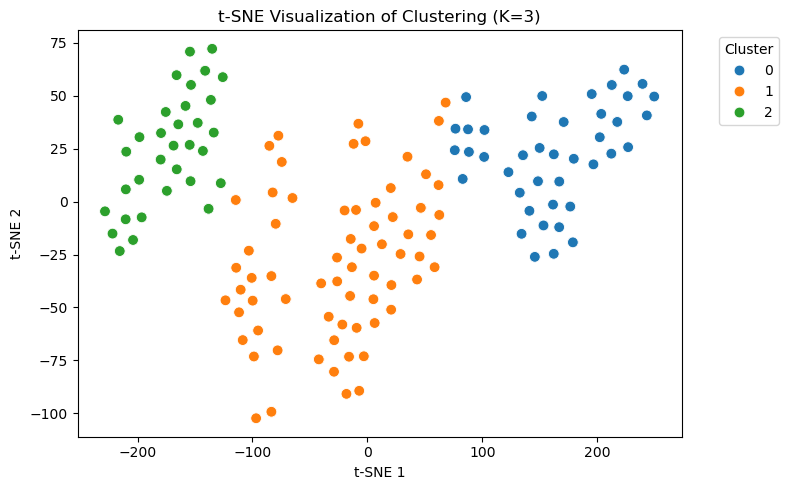

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

# 1. Load the data
df = pd.read_csv("carprices.csv")

# 2. Scale the features
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# 3. Search for K in {2, 3, 4, 5, 6}
k_values = [2, 3, 4, 5, 6]
inertia_list = []
silhouette_list = []
cluster_counts_dict = {}

for k in np.arange(2, 21, 1):
    # Initialize and fit KMeans with required settings
    kmeans = KMeans(n_clusters=k, 
                    init='random', 
                    n_init=20, 
                    random_state=9001)
    labels = kmeans.fit_predict(df_scaled)
    
    # Metrics
    inertia_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(df_scaled, labels))
    
    # Cluster counts (samples per cluster)
    unique, counts = np.unique(labels, return_counts=True)
    cluster_counts_dict[k] = dict(zip(unique, counts))
    
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette Score={silhouette_list[-1]:.4f}")
    print(f"   Cluster Counts: {cluster_counts_dict[k]}")

# 4. Elbow check: find the largest drop in inertia
inertia_drops = np.diff(inertia_list) # Calculates diffs between k and k-1
# Note: diff returns [i1-i0, i2-i1, ...]. We want the largest absolute drop.
largest_drop_idx = np.argmin(inertia_drops) # Largest negative value is largest drop
optimal_k_elbow = k_values[largest_drop_idx + 1]

print(f"\n--- Optimal K Results ---")
print(f"Optimal K according to Elbow Method (largest drop): {optimal_k_elbow}")

# 5. Final Visualization (using optimal K from elbow check, e.g., K=3)
final_clusters = KMeans(n_clusters=optimal_k_elbow, init='random', n_init=20, random_state=9001)
labels_final = final_clusters.fit_predict(df_scaled)

tsne = TSNE(n_components=2, random_state=42)
tsnes = tsne.fit_transform(df_scaled)
df_tsne = pd.DataFrame({'TSNE1': tsnes[:, 0], 'TSNE2': tsnes[:, 1], 'Cluster': labels_final})

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='Cluster', palette='tab10', s=60)
plt.title(f't-SNE Visualization of Clustering (K={optimal_k_elbow})')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

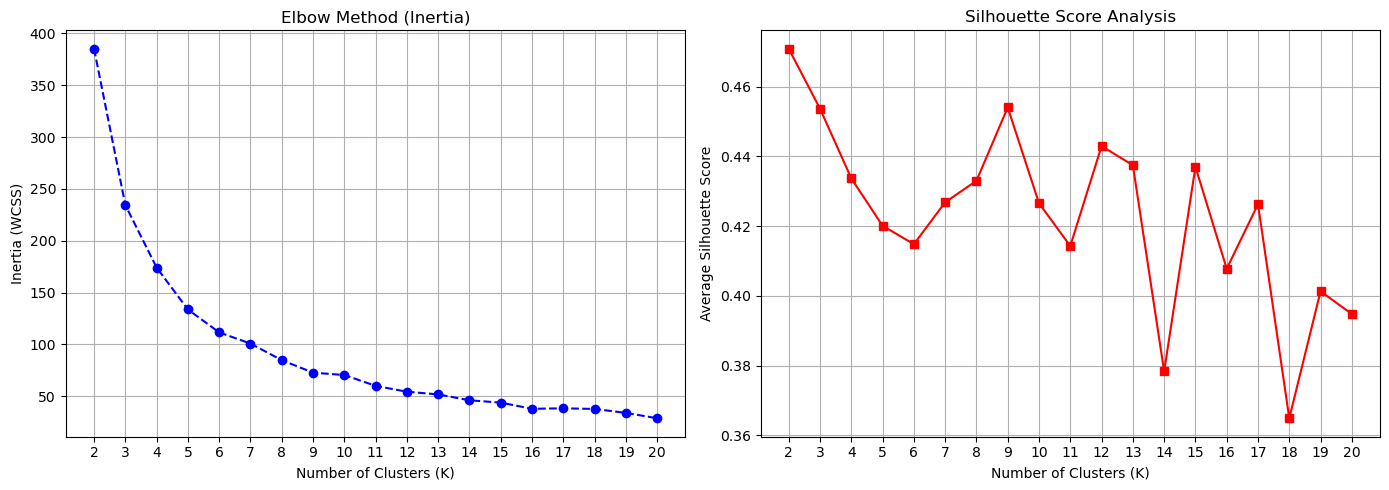

In [34]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Initialize lists to store metrics
k_values =np.arange(2, 21, 1)
inertia_list = []
silhouette_list = []

# 2. Run the loop for different K values
for k in k_values:
    kmeans = KMeans(n_clusters=k, init='random', n_init=20, random_state=9001)
    labels = kmeans.fit_predict(df_scaled)
    
    inertia_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(df_scaled, labels))

# 3. Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow Method (Inertia)
ax1.plot(k_values, inertia_list, marker='o', color='b', linestyle='--')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_xticks(k_values)
ax1.grid(True)

# Plot 2: Silhouette Score
ax2.plot(k_values, silhouette_list, marker='s', color='r', linestyle='-')
ax2.set_title('Silhouette Score Analysis')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Average Silhouette Score')
ax2.set_xticks(k_values)
ax2.grid(True)

plt.tight_layout()
plt.savefig('clustering_metrics.png')

In [39]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# load data
df = pd.read_csv("carprices.csv")
print(df.shape)
print(df.head())

(205, 4)
   enginesize  horsepower  citympg  highwaympg
0         130         111       21          27
1         130         111       21          27
2         152         154       19          26
3         109         102       24          30
4         136         115       18          22


In [42]:
# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# search for K in {2, 3, 4, 5, 6}
# K_values = np.arange(2,30,1)
K_values = [2, 3, 4, 5, 6]
inertias    = []
sil_scores  = []
cluster_counts = {}

print("K-Means Clustering Results")
print("=" * 60)

for k in K_values:
    kmeans = KMeans(
        n_clusters  = k,
        init        = 'random',
        random_state= 9001,
        n_init      = 20
    )
    kmeans.fit(X_scaled)
    
    # inertia (WCSS)
    inertia = kmeans.inertia_
    inertias.append(inertia)
    
    # silhouette score
    sil = silhouette_score(X_scaled, kmeans.labels_)
    sil_scores.append(sil)
    
    # cluster counts
    counts = pd.Series(kmeans.labels_).value_counts().sort_index()
    cluster_counts[k] = counts
    
    print(f"\nK = {k}")
    print(f"  Inertia          : {inertia:.2f}")
    print(f"  Silhouette Score : {sil:.4f}")
    print(f"  Cluster counts   : {counts.to_dict()}")

# elbow check — drop in inertia between consecutive K values
print("\n\nElbow Check — Drop in Inertia")
print("=" * 40)
drops = {}
for i in range(1, len(K_values)):
    drop = inertias[i-1] - inertias[i]
    drops[K_values[i]] = drop
    print(f"  K={K_values[i-1]} -> K={K_values[i]}: drop = {drop:.2f}")

optimal_k_elbow = max(drops, key=drops.get)
print(f"\nLargest drop at K = {optimal_k_elbow} — optimal K by elbow method")

# optimal K by silhouette
optimal_k_sil = K_values[np.argmax(sil_scores)]
print(f"Highest silhouette at K = {optimal_k_sil} — optimal K by silhouette method")

K-Means Clustering Results

K = 2
  Inertia          : 385.23
  Silhouette Score : 0.4708
  Cluster counts   : {0: 85, 1: 120}



K = 3
  Inertia          : 234.45
  Silhouette Score : 0.4537
  Cluster counts   : {0: 61, 1: 98, 2: 46}

K = 4
  Inertia          : 174.14
  Silhouette Score : 0.4337
  Cluster counts   : {0: 15, 1: 41, 2: 88, 3: 61}

K = 5
  Inertia          : 133.71
  Silhouette Score : 0.4201
  Cluster counts   : {0: 15, 1: 52, 2: 41, 3: 80, 4: 17}

K = 6
  Inertia          : 111.62
  Silhouette Score : 0.4148
  Cluster counts   : {0: 15, 1: 46, 2: 63, 3: 17, 4: 33, 5: 31}


Elbow Check — Drop in Inertia
  K=2 -> K=3: drop = 150.78
  K=3 -> K=4: drop = 60.31
  K=4 -> K=5: drop = 40.43
  K=5 -> K=6: drop = 22.09

Largest drop at K = 3 — optimal K by elbow method
Highest silhouette at K = 2 — optimal K by silhouette method


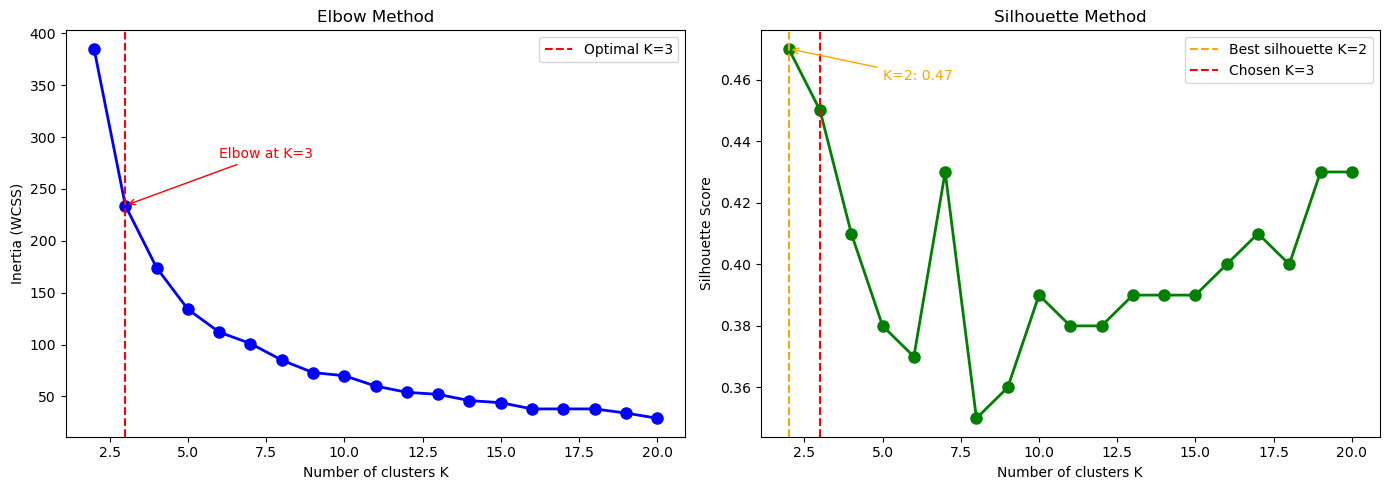

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Elbow curve ───────────────────────────────────────────────────────────────
ks        = list(range(2, 21))
inertias  = [385, 234, 174, 134, 112, 101, 85, 73, 70, 60, 54, 52, 46, 44, 38, 38, 38, 34, 29]

axes[0].plot(ks, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', label='Optimal K=3')
axes[0].set_xlabel('Number of clusters K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].legend()

# annotate the elbow point
axes[0].annotate('Elbow at K=3',
    xy=(3, 234), xytext=(6, 280),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red', fontsize=10)

# ── Silhouette scores ─────────────────────────────────────────────────────────
silhouettes = [0.47, 0.45, 0.41, 0.38, 0.37, 0.43, 0.35, 0.36, 0.39,
               0.38, 0.38, 0.39, 0.39, 0.39, 0.40, 0.41, 0.40, 0.43, 0.43]

axes[1].plot(ks, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=2, color='orange', linestyle='--', label='Best silhouette K=2')
axes[1].axvline(x=3, color='red',    linestyle='--', label='Chosen K=3')
axes[1].set_xlabel('Number of clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Method')
axes[1].legend()

# annotate peaks
axes[1].annotate(f'K=2: {0.47}',
    xy=(2, 0.47), xytext=(5, 0.46),
    arrowprops=dict(arrowstyle='->', color='orange'),
    color='orange', fontsize=10)

plt.tight_layout()
plt.show()
